In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Load datasets
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print("--- Fraud Data Info ---")
print(fraud_df.info())
print("\nMissing values in Fraud Data:\n", fraud_df.isnull().sum())
print("Duplicates in Fraud Data:", fraud_df.duplicated().sum())

print("\n--- IP Data Info ---")
print(ip_df.info())
print("\nMissing values in IP Data:\n", ip_df.isnull().sum())
print("Duplicates in IP Data:", ip_df.duplicated().sum())
print("Fraud shape:", fraud_df.shape)
print("IP-Country shape:", ip_df.shape)

--- Fraud Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB
None

Missing values in Fraud Data:
 user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip

In [40]:

print("--- Data Types BEFORE Correction ---")
print(fraud_df[['signup_time', 'purchase_time', 'ip_address']].dtypes)
print("-" * 35)

# 2. Convert signup_time and purchase_time from object to datetime64
# Using errors='coerce' ensures that if there are any corrupt strings, they safely turn to NaT instead of crashing
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'], errors='coerce')
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'], errors='coerce')

# 3. Convert ip_address from float to int64 for clean range-based lookups
# Note: if there were missing values, float couldn't cast to int64, but we verified earlier it is clean!
fraud_df['ip_address'] = fraud_df['ip_address'].astype('int64')
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype('int64')

print("\n--- Data Types AFTER Correction ---")
print(fraud_df[['signup_time', 'purchase_time', 'ip_address']].dtypes)

--- Data Types BEFORE Correction ---
signup_time      datetime64[us]
purchase_time    datetime64[us]
ip_address                int64
dtype: object
-----------------------------------

--- Data Types AFTER Correction ---
signup_time      datetime64[us]
purchase_time    datetime64[us]
ip_address                int64
dtype: object


univariant analysis 

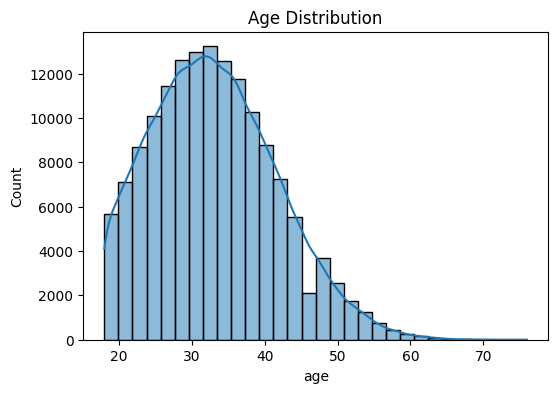

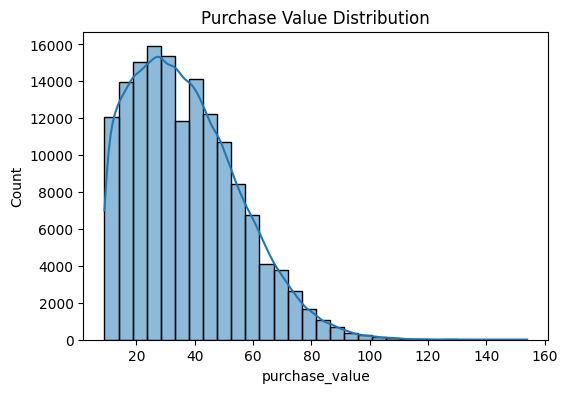

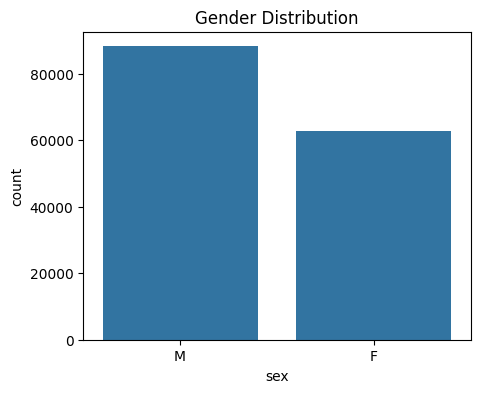

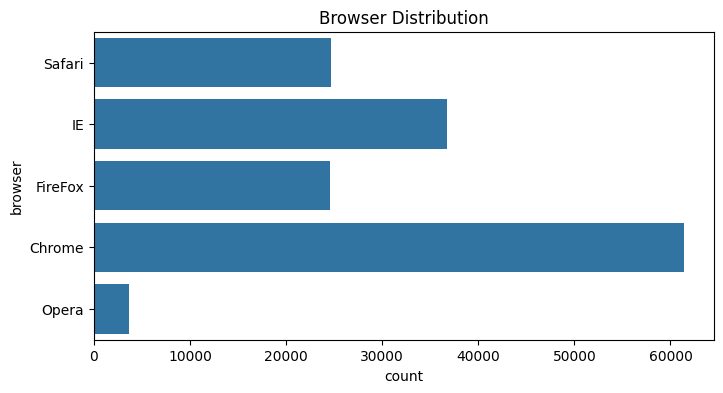

In [41]:
# Histogram of age
plt.figure(figsize=(6,4))
sns.histplot(fraud_df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


# Histogram of purchase value
plt.figure(figsize=(6,4))
sns.histplot(fraud_df['purchase_value'], bins=30, kde=True)
plt.title("Purchase Value Distribution")
plt.show()


# Gender
plt.figure(figsize=(5,4))
sns.countplot(x='sex', data=fraud_df)
plt.title("Gender Distribution")
plt.show()


# Browser
plt.figure(figsize=(8,4))
sns.countplot(y='browser', data=fraud_df)
plt.title("Browser Distribution")
plt.show()

Bivariant analysis

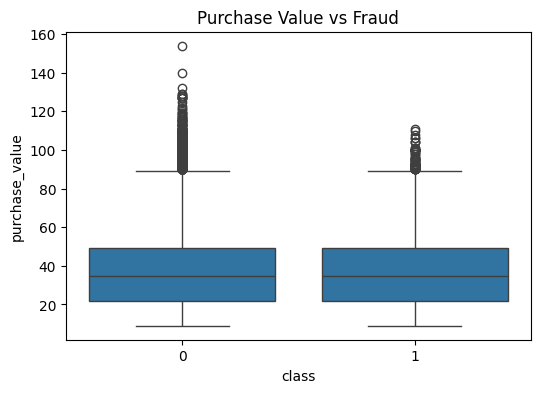

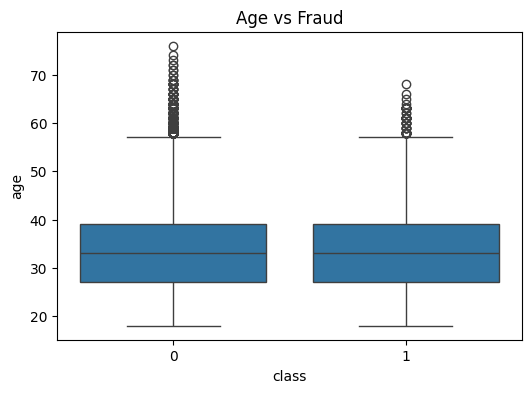

In [42]:
# Fraud class vs purchase value
plt.figure(figsize=(6,4))
sns.boxplot(x='class', y='purchase_value', data=fraud_df)
plt.title("Purchase Value vs Fraud")
plt.show()


# Fraud class vs age
plt.figure(figsize=(6,4))
sns.boxplot(x='class', y='age', data=fraud_df)
plt.title("Age vs Fraud")
plt.show()

Class imbalalnce 


Class distribution:
class
0    136961
1     14151
Name: count, dtype: int64

Percentage:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


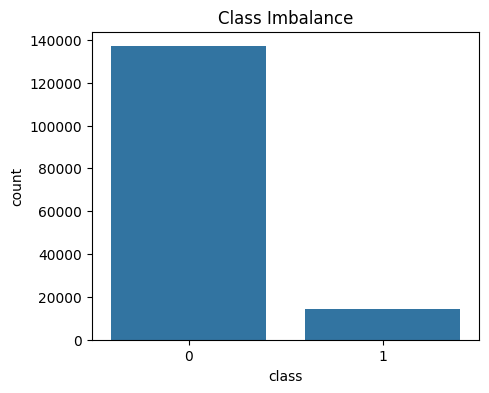

In [43]:
class_counts = fraud_df['class'].value_counts()

print("\nClass distribution:")
print(class_counts)

print("\nPercentage:")
print(fraud_df['class'].value_counts(normalize=True)*100)


plt.figure(figsize=(5,4))
sns.countplot(x='class', data=fraud_df)
plt.title("Class Imbalance")
plt.show()

In [44]:
print(fraud_df['ip_address'].dtype)
print(ip_df['lower_bound_ip_address'].dtype)
print(ip_df['upper_bound_ip_address'].dtype)

int64
int64
int64


In [45]:
fraud_df= fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

In [46]:
merged_data = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Keep only rows inside the interval
merged_data = merged_data[
    merged_data['ip_address'] <= merged_data['upper_bound_ip_address']
]

print(merged_data[['ip_address','country']].head())

     ip_address    country
634    16778864  Australia
635    16842045   Thailand
636    16843656      China
637    16938732      China
638    16971984   Thailand


Fraud Patterns by Country

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Ireland                  0.229167
New Zealand              0.223022
Uzbekistan               0.200000
Lithuania                0.189474
Saudi Arabia             0.189394
Malta                    0.181818
Afghanistan              0.166667
Cote D'ivoire            0.166667
Denmark                  0.159184
Chile                    0.153477
Name: class, dtype: float64


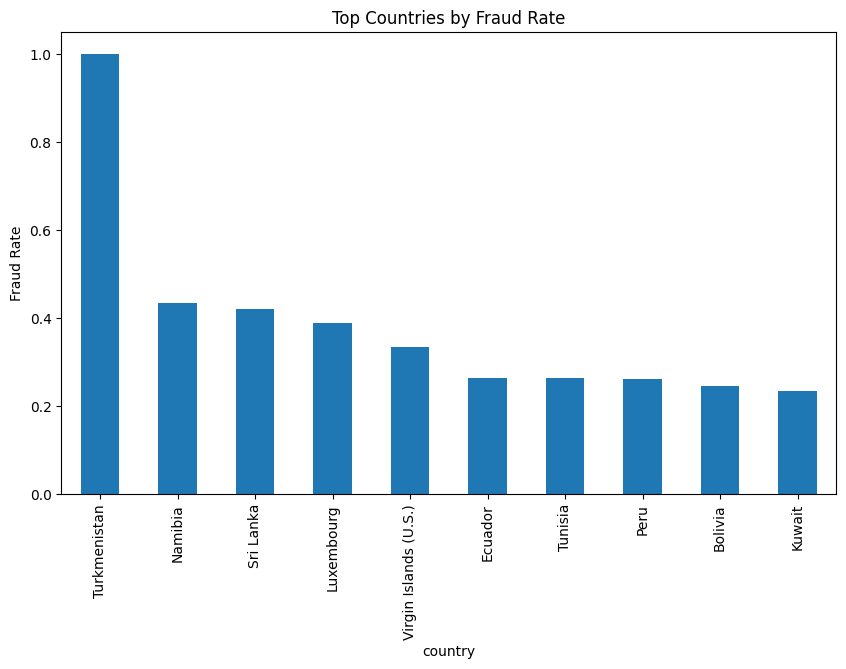

In [47]:
country_fraud = (
    merged_data.groupby('country')['class']
    .mean()
    .sort_values(ascending=False)
)

print(country_fraud.head(20))


plt.figure(figsize=(10,6))
country_fraud.head(10).plot(kind='bar')
plt.ylabel("Fraud Rate")
plt.title("Top Countries by Fraud Rate")
plt.show()

Feature Engineering
Hour of day

In [48]:
merged_data['hour_of_day'] = (
    merged_data['purchase_time'].dt.hour
)

Day of week

In [49]:
merged_data['day_of_week'] = (
    merged_data['purchase_time'].dt.dayofweek
)

Time since signup

In [50]:
merged_data['time_since_signup'] = (
    merged_data['purchase_time']
    - merged_data['signup_time']
).dt.total_seconds() / 3600

print(merged_data['time_since_signup'].head())

634    1008.948611
635     342.121389
636     554.870556
637    2122.471389
638    2847.105278
Name: time_since_signup, dtype: float64


Transaction Frequency per User

In [51]:
merged_data['transaction_count'] = (
    merged_data.groupby('user_id')['user_id']
    .transform('count')
)

Transaction Velocity

Sort by user and purchase time

In [52]:
merged_data = merged_data.sort_values(
    ['user_id','purchase_time']
)

merged_data['previous_purchase'] = (
    merged_data.groupby('user_id')['purchase_time']
    .shift()
)

merged_data['time_between_transactions'] = (
    merged_data['purchase_time']
    - merged_data['previous_purchase']
).dt.total_seconds()/3600

merged_data['time_between_transactions'] = (
    merged_data['time_between_transactions']
    .fillna(0)
)

Data Transformation
One-hot Encoding

In [53]:
categorical_cols = [
    'source',
    'browser',
    'sex',
    'country'
]

data_encoded = pd.get_dummies(
    merged_data,
    columns=categorical_cols,
    drop_first=True
)

Feature Matrix and Target

In [54]:
X = data_encoded.drop(
    columns=[
        'class',
        'signup_time',
        'purchase_time',
        'device_id',
        'previous_purchase'
    ]
)

y = data_encoded['class']

Train-Test Split

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Scaling Numerical Variables

In [56]:
numeric_cols = [
    'purchase_value',
    'age',
    'hour_of_day',
    'day_of_week',
    'time_since_signup',
    'transaction_count',
    'time_between_transactions'
]

scaler = StandardScaler()

X_train[numeric_cols] = scaler.fit_transform(
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform(
    X_test[numeric_cols]
)

Handle Class Imbalance with SMOTE
Distribution Before SMOTE

In [57]:
print("\nBefore SMOTE")
print(y_train.value_counts())


Before SMOTE
class
0    93502
1     9814
Name: count, dtype: int64


Apply SMOTE

In [58]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

Distribution After SMOTE

In [59]:
print("\nAfter SMOTE")
print(y_train_smote.value_counts())


After SMOTE
class
0    93502
1    93502
Name: count, dtype: int64


Visualize Before and After

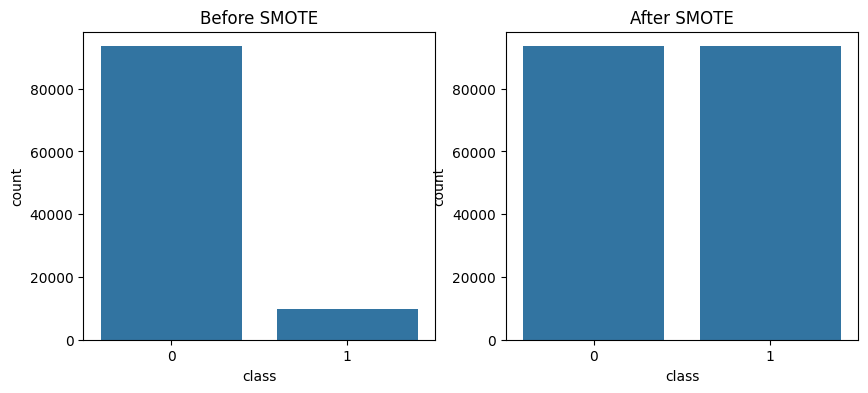

In [60]:
fig, axes = plt.subplots(1,2, figsize=(10,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")

plt.show()

Save Cleaned Dataset

In [61]:
merged_data.to_csv(
    "Fraud_Data_Cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
